# EfficientNetB0 — Training & Evaluation (C1, C2, C3)

- **C1 (Replica):** Exact reproduction of reference (frozen base, simple head)
- **C2 (Improved):** Freeze-then-unfreeze with expanded head
- **C3 (Tuned):** Keras Tuner hyperparameter optimization

## 1. Setup

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]  # 4 GB
    )


2026-07-17 02:38:04.616963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-17 02:38:04.653427: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-17 02:38:04.669486: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-17 02:38:04.698962: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784255888.589422    1747 c

In [3]:
# Standard library
import os
import random
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L2
import keras_tuner as kt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.17.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

DATASET_PATH = Path("/workspaces/ODL_ASSIGNMENT/ODL/dataset")

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 6
EPOCHS_BASELINE = 100      # Custom CNN improved configs
EPOCHS_PRETRAINED = 50     # Transfer learning improved configs
EPOCHS_TUNER = 30          # Keras Tuner trials
EPOCHS_REPLICA = 20        # Replica configs (matching reference)

# Set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Create output directories
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("logs", exist_ok=True)

print("Configuration set.")

Configuration set.


## 2. Data Pipeline

In [5]:
def load_dataset(dataset_path: Path) -> pd.DataFrame:
    """Walk dataset directory, collect image paths and labels. Skips yolo folders."""
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {dataset_path}")
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    records = []
    class_folders = [f for f in dataset_path.iterdir() if f.is_dir()]
    for class_folder in sorted(class_folders):
        class_name = class_folder.name
        if 'yolo' in class_name.lower():
            print(f"  [SKIPPED] {class_name}")
            continue
        class_count = 0
        for root, dirs, files in os.walk(class_folder):
            dirs[:] = [d for d in dirs if 'yolo' not in d.lower()]
            for fname in files:
                ext = os.path.splitext(fname)[1].lower()
                if ext in valid_extensions:
                    filepath = os.path.join(root, fname)
                    records.append({'filepath': filepath, 'label': class_name})
                    class_count += 1
        if class_count == 0:
            print(f"  [WARNING] No images in: {class_name}")
        else:
            print(f"  [OK] {class_name}: {class_count} images")
    if len(records) == 0:
        raise ValueError("No valid images found.")
    return pd.DataFrame(records)

# Load dataset
df = load_dataset(DATASET_PATH)
CLASS_NAMES = sorted(df['label'].unique().tolist())
LABEL_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print(f"\nTotal: {len(df)} images, Classes: {CLASS_NAMES}")

# Stratified 70/15/15 split
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=47, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=47, stratify=temp_df['label'])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

  [OK] Calculus: 1296 images
  [SKIPPED] Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
  [OK] Data caries: 2601 images
  [OK] Gingivitis: 2349 images


  [OK] Mouth Ulcer: 2806 images
  [OK] Tooth Discoloration: 2017 images
  [OK] hypodontia: 1251 images

Total: 12320 images, Classes: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']
Train: 8624 | Val: 1848 | Test: 1848


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def process_path(filepath, label):
    """Read, decode, resize, normalize image; one-hot encode label."""
    img = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

def build_dataset(dataframe, is_training=False):
    """Build batched, prefetched tf.data.Dataset from DataFrame."""
    filepaths = dataframe['filepath'].values
    labels = dataframe['label'].map(LABEL_TO_INDEX).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, is_training=True)
val_ds = build_dataset(val_df, is_training=False)
test_ds = build_dataset(test_df, is_training=False)
print("Datasets built successfully.")

I0000 00:00:1784255893.775052    1747 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784255893.775144    1747 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784255893.775187    1747 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784255894.762903    1747 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-17 02:38:14.763234: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2112] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.

Datasets built successfully.


## 3. Utilities

In [7]:
def get_augmentation_layers():
    """Augmentation layers embedded inside models (active only during training)."""
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
    ], name="augmentation")


def get_callbacks(checkpoint_path):
    """Fresh callback instances for each training run."""
    return [
        keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.1, patience=8),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path, save_best_only=True, monitor="val_accuracy", mode="max"
        )
    ]


def save_history(history, filepath):
    """Save training history to CSV for later analysis."""
    hist = history if isinstance(history, dict) else history.history
    hist_df = pd.DataFrame(hist)
    hist_df.index.name = 'epoch'
    hist_df.to_csv(filepath)
    print(f"  History saved to: {filepath}")


def plot_training_history(history, model_name):
    """
    Plot training curves matching reference style:
    - Blue = Train, Red = Validation
    - Green dashed vertical line at best epoch
    - Green dot with annotation at best value
    - Text summary below
    """
    hist = history if isinstance(history, dict) else history.history
    
    epochs = range(1, len(hist['accuracy']) + 1)
    best_epoch = np.argmax(hist['val_accuracy'])
    best_val_acc = hist['val_accuracy'][best_epoch]
    best_val_loss = hist['val_loss'][best_epoch]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Accuracy plot ---
    ax1.plot(epochs, hist['accuracy'], 'b-', linewidth=2, label='Train Accuracy')
    ax1.plot(epochs, hist['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
    ax1.axvline(x=best_epoch + 1, color='green', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best_epoch + 1})')
    ax1.scatter(best_epoch + 1, best_val_acc, color='green', s=100, zorder=5)
    ax1.annotate(f'Acc: {best_val_acc:.4f}', xy=(best_epoch + 1, best_val_acc),
                 xytext=(best_epoch + 2, best_val_acc), fontsize=9, color='green')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'{model_name} Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # --- Loss plot ---
    ax2.plot(epochs, hist['loss'], 'b-', linewidth=2, label='Train Loss')
    ax2.plot(epochs, hist['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    ax2.axvline(x=best_epoch + 1, color='green', linestyle='--', linewidth=1.5, label=f'Best Epoch ({best_epoch + 1})')
    ax2.scatter(best_epoch + 1, best_val_loss, color='green', s=100, zorder=5)
    ax2.annotate(f'Loss: {best_val_loss:.4f}', xy=(best_epoch + 1, best_val_loss),
                 xytext=(best_epoch + 2, best_val_loss), fontsize=9, color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title(f'{model_name} Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary text
    print(f"  Best Epoch: {best_epoch + 1}")
    print(f"  Highest Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"  Lowest Validation Loss: {best_val_loss:.4f}")


def evaluate_model(model, train_ds, val_ds, test_ds, class_names, model_name):
    """Evaluate model on all splits, show classification report and confusion matrix."""
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    print(f"\n{'='*50}")
    print(f"{model_name} — Evaluation Results")
    print(f"{'='*50}")
    print(f"  Train — Acc: {train_acc:.4f}, Loss: {train_loss:.4f}")
    print(f"  Val   — Acc: {val_acc:.4f}, Loss: {val_loss:.4f}")
    print(f"  Test  — Acc: {test_acc:.4f}, Loss: {test_loss:.4f}")
    
    # Classification Report
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds])
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return {
        'model_name': model_name,
        'params_m': round(model.count_params() / 1e6, 2),
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'test_loss': test_loss,
    }

## 4. EfficientNetB0 — C1 (Replica)

Exact replica of reference: EfficientNetB0 frozen, GAP → Dense(128) → Dropout(0.5) → Dense(6). Adam(lr=0.0001), 20 epochs.

16705208/16705208 [==============================] - 5s 0us/step
Model: "EfficientNetB0_C1_Replica"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 6)                 774       
                                          

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  4/539 [..............................] - ETA: 24s - loss: 1.7927 - accuracy: 0.2188   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1784255920.165415    2093 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255920.165858    2093 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255920.166161    2093 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255920.166725    2093 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255920.167157    2093 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255920.167640    2093 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255920.168349    2093 gpu_timer.cc:114] Skipping

538/539 [============================>.] - ETA: 0s - loss: 1.7628 - accuracy: 0.2185

W0000 00:00:1784255944.452637    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.452842    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.452998    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.453199    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.453418    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.453691    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.454032    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.454429    2098 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255944.455034    2098 gp

539/539 [==============================] - 39s 46ms/step - loss: 1.7629 - accuracy: 0.2183 - val_loss: 1.7513 - val_accuracy: 0.2110 - lr: 1.0000e-04
Epoch 2/20
538/539 [============================>.] - ETA: 0s - loss: 1.7558 - accuracy: 0.2203

W0000 00:00:1784255968.409869    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.410070    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.410256    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.410479    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.410692    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.410984    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.411310    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.411611    2096 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1784255968.411984    2096 gp

539/539 [==============================] - 24s 43ms/step - loss: 1.7558 - accuracy: 0.2201 - val_loss: 1.7506 - val_accuracy: 0.2278 - lr: 1.0000e-04
Epoch 3/20
539/539 [==============================] - 24s 44ms/step - loss: 1.7556 - accuracy: 0.2180 - val_loss: 1.7481 - val_accuracy: 0.2110 - lr: 1.0000e-04
Epoch 4/20
539/539 [==============================] - 22s 40ms/step - loss: 1.7526 - accuracy: 0.2200 - val_loss: 1.7485 - val_accuracy: 0.2278 - lr: 1.0000e-04
Epoch 5/20
539/539 [==============================] - 23s 37ms/step - loss: 1.7535 - accuracy: 0.2260 - val_loss: 1.7471 - val_accuracy: 0.2278 - lr: 1.0000e-04
Epoch 6/20
539/539 [==============================] - 23s 42ms/step - loss: 1.7544 - accuracy: 0.2203 - val_loss: 1.7473 - val_accuracy: 0.2278 - lr: 1.0000e-04
Epoch 7/20
539/539 [==============================] - 24s 43ms/step - loss: 1.7548 - accuracy: 0.2231 - val_loss: 1.7477 - val_accuracy: 0.2278 - lr: 1.0000e-04
Epoch 8/20
539/539 [=========================

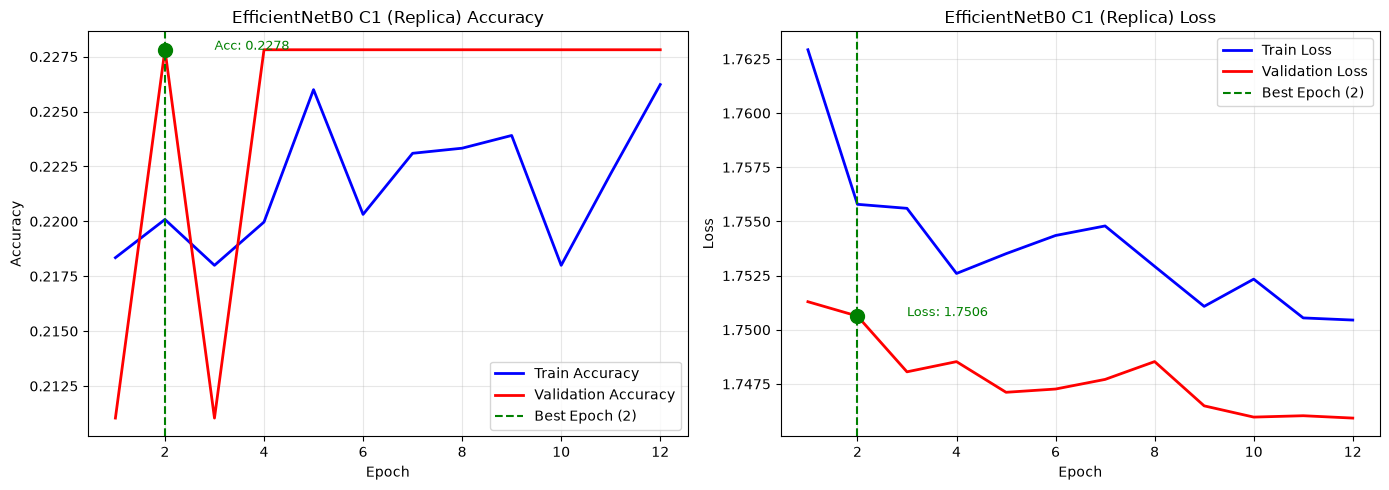

  Best Epoch: 2
  Highest Validation Accuracy: 0.2278 (22.78%)
  Lowest Validation Loss: 1.7506


In [8]:
# --- EfficientNetB0 C1: Exact replica ---

def build_efficientnet_c1():
    base = keras.applications.EfficientNetB0(
        weights="imagenet", include_top=False, input_shape=(224, 224, 3)
    )
    base.trainable = False  # Frozen (same as reference)
    
    model = keras.Sequential([
        keras.Input(shape=(224, 224, 3)),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="EfficientNetB0_C1_Replica")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

eff_c1 = build_efficientnet_c1()
eff_c1.summary()

history_eff_c1 = eff_c1.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_REPLICA,
    callbacks=get_callbacks("checkpoints/eff_c1_best.h5")
)

save_history(history_eff_c1, "logs/eff_c1_history.csv")
plot_training_history(history_eff_c1, "EfficientNetB0 C1 (Replica)")


EfficientNetB0 C1 — Evaluation Results
  Train — Acc: 0.2277, Loss: 1.7506
  Val   — Acc: 0.2278, Loss: 1.7506
  Test  — Acc: 0.2278, Loss: 1.7506


2026-07-17 02:43:50.041858: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param


Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.00      0.00      0.00       194
        Data caries       0.00      0.00      0.00       390
         Gingivitis       0.00      0.00      0.00       352
        Mouth Ulcer       0.23      1.00      0.37       421
Tooth Discoloration       0.00      0.00      0.00       303
         hypodontia       0.00      0.00      0.00       188

           accuracy                           0.23      1848
          macro avg       0.04      0.17      0.06      1848
       weighted avg       0.05      0.23      0.08      1848



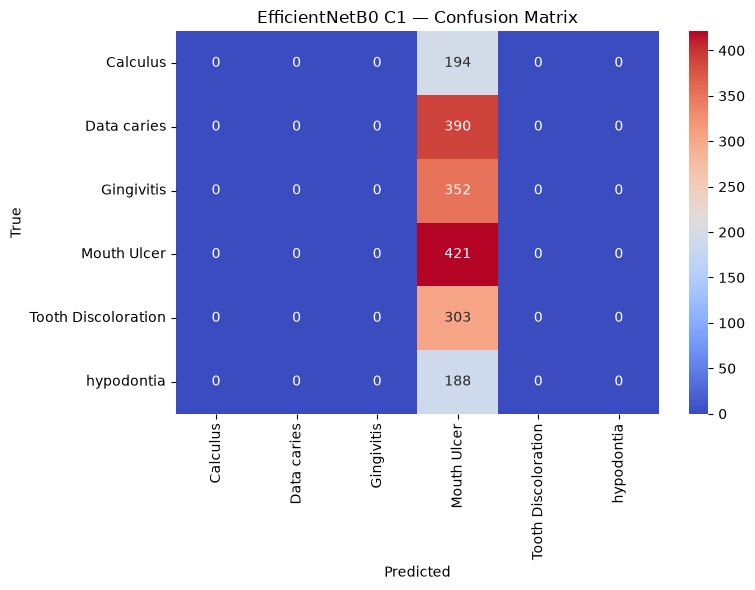

In [9]:
# Evaluate EfficientNetB0 C1
eff_c1.load_weights("checkpoints/eff_c1_best.h5")
result_eff_c1 = evaluate_model(eff_c1, train_ds, val_ds, test_ds, CLASS_NAMES, "EfficientNetB0 C1")

## 5. EfficientNetB0 — C2 (Improved)

Freeze-then-unfreeze strategy with expanded head: GAP → BN → Dense(512) → Dense(256) → Dense(6). Phase 1: frozen 10 epochs. Phase 2: unfrozen 40 epochs.

In [10]:
# --- EfficientNetB0 C2: Freeze then Unfreeze ---

def build_efficientnet_c2():
    inputs = keras.Input(shape=(224, 224, 3))
    x = get_augmentation_layers()(inputs)
    
    base = keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=x
    )
    base.trainable = False  # Freeze initially
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=L2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=L2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='EfficientNetB0_C2_Improved')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base

eff_c2, eff_c2_base = build_efficientnet_c2()
eff_c2.summary()
print("\nEfficientNetB0 C2 — Phase 1 (frozen base, 10 epochs)")

# Phase 1: Train head only
history_p1 = eff_c2.fit(
    train_ds, validation_data=val_ds,
    epochs=10,
    callbacks=get_callbacks("checkpoints/eff_c2_best.h5")
)

# Phase 2: Unfreeze and fine-tune
print("\nPhase 2: Unfreezing base model (40 epochs)...")
eff_c2_base.trainable = True
eff_c2.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
               loss='categorical_crossentropy', metrics=['accuracy'])

history_p2 = eff_c2.fit(
    train_ds, validation_data=val_ds,
    epochs=40,
    callbacks=get_callbacks("checkpoints/eff_c2_best.h5")
)

# Concatenate histories
history_eff_c2 = {}
for key in history_p1.history:
    history_eff_c2[key] = history_p1.history[key] + history_p2.history[key]

save_history(history_eff_c2, "logs/eff_c2_history.csv")
plot_training_history(history_eff_c2, "EfficientNetB0 C2 (Improved)")

Model: "EfficientNetB0_C2_Improved"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 augmentation (Sequential)   (None, 224, 224, 3)          0         ['input_3[0][0]']             
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['augmentation[0][0]']        
                                                                                                  
 normalization_1 (Normaliza  (None, 224, 224, 3)          7         ['rescaling_1[0][0]']         
 tion)                                                                   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  5/539 [..............................] - ETA: 19s - loss: 2.0978 - accuracy: 0.1000   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


331/539 [=================>............] - ETA: 7s - loss: 1.9880 - accuracy: 0.2035

KeyboardInterrupt: 

In [ ]:
# Evaluate EfficientNetB0 C2
eff_c2.load_weights("checkpoints/eff_c2_best.h5")
result_eff_c2 = evaluate_model(eff_c2, train_ds, val_ds, test_ds, CLASS_NAMES, "EfficientNetB0 C2")

## 6. EfficientNetB0 — C3 (Keras Tuner)

BayesianOptimization with frozen base. Search: dense_units, dropout, l2_rate, learning_rate.

In [ ]:
# --- EfficientNetB0 C3: Keras Tuner ---

def build_efficientnet_c3(hp):
    inputs = keras.Input(shape=(224, 224, 3))
    x = get_augmentation_layers()(inputs)
    
    base = keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=x
    )
    base.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    
    dense_units = hp.Choice('dense_units', values=[128, 256, 512])
    dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.6, step=0.1)
    l2_rate = hp.Choice('l2_rate', values=[1e-3, 5e-4, 1e-4])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4, 5e-5])
    
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=L2(l2_rate))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='EfficientNetB0_C3_Tuned')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

tuner_eff = kt.BayesianOptimization(
    build_efficientnet_c3,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='efficientnet_c3',
    overwrite=True
)

print("Starting EfficientNetB0 Keras Tuner search...")
tuner_eff.search(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_TUNER,
    callbacks=get_callbacks("checkpoints/eff_c3_search_best.h5")
)

best_hp_eff = tuner_eff.get_best_hyperparameters(1)[0]
print(f"\nBest EfficientNetB0 hyperparameters:")
print(f"  dense_units: {best_hp_eff.get('dense_units')}")
print(f"  dropout_rate: {best_hp_eff.get('dropout_rate')}")
print(f"  l2_rate: {best_hp_eff.get('l2_rate')}")
print(f"  learning_rate: {best_hp_eff.get('learning_rate')}")

In [ ]:
# Retrain best EfficientNetB0 C3
eff_c3 = tuner_eff.hypermodel.build(best_hp_eff)
eff_c3.summary()

history_eff_c3 = eff_c3.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_PRETRAINED,
    callbacks=get_callbacks("checkpoints/eff_c3_best.h5")
)

save_history(history_eff_c3, "logs/eff_c3_history.csv")
plot_training_history(history_eff_c3, "EfficientNetB0 C3 (Tuned)")

eff_c3.load_weights("checkpoints/eff_c3_best.h5")
result_eff_c3 = evaluate_model(eff_c3, train_ds, val_ds, test_ds, CLASS_NAMES, "EfficientNetB0 C3")

## 7. EfficientNetB0 Family — Mini Comparison

In [ ]:
eff_results = pd.DataFrame([result_eff_c1, result_eff_c2, result_eff_c3])
eff_results['Test Acc (%)'] = (eff_results['test_acc'] * 100).round(2)
eff_results['Val Acc (%)'] = (eff_results['val_acc'] * 100).round(2)
print("\n=== EfficientNetB0 Family Comparison ===")
display(eff_results[['model_name', 'params_m', 'Val Acc (%)', 'Test Acc (%)', 'test_loss']].to_string(index=False))